<a href="https://colab.research.google.com/github/flynnight/Tubes-Siscer/blob/main/ML_Medical_Insurance_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Komparasi K-Nearest Neighbor dan Decision Tree untuk Prediksi Biaya Asuransi Kesehatan dengan Feature Engineering dan Log Transformasi**

---
> **Level 2: AI-Assisted Idea Generation & Structuring**
---

## **1. Topik & Identitas**

Judul Studi Kasus: Perbandingan K-Nearest Neighbor dan Decision Tree untuk Prediksi Biaya Asuransi Kesehatan pada Medical Charges Insurance Dataset

| Nama | NIM |
|------|-----|
| Fathahul Rizqa Arrahman | 103032430013 |
| Febriani Zahra | 103032400034 |
| Muhammad Maulana Darmawansyah | 103032400081 |



---
## 📦 Instalasi & Import Library

In [1]:
#untuk membaca dan mengolah dataset dalam bentuk tabel
import pandas as pd
#untuk operasi matematika dll
import numpy as np

#untuk membuat grafik (x, y)
import matplotlib.pyplot as plt
#untuk scatter plot
import matplotlib.ticker as mticker
#untuk memperjelas grafik yang dibuat oleh matplotlib
import seaborn as sns

#mengubah data teks menjadi angka
from sklearn.preprocessing import LabelEncoder
#menyamakan skala data
from sklearn.preprocessing import StandardScaler

#untuk melakukan cross validation
from sklearn.model_selection import KFold
#mencari parameter yang terbaik secara otomatis
from sklearn.model_selection import GridSearchCV
#menghasilkan prediksi dengan cross validation
from sklearn.model_selection import cross_val_predict
#untuk R^2 Score
from sklearn.model_selection import cross_val_score

#model KNN untuk regresi
from sklearn.neighbors import KNeighborsRegressor
#model DT untuk regresi
from sklearn.tree import DecisionTreeRegressor

#berguna untuk mengukur kualitas dari model yang dipake
from sklearn.metrics import (
    #MAE (mean_absolute_error) berguna untuk menghitung rata-rata selisih absolut antara nilai sebenernya dengan nilai prediksi
    mean_absolute_error,
    #RMSE (root_mean_squared_error) berguna untuk menghitung akar kuadrat dari rata-rata selisih kuadrat antara nilai sebenernya dengan nilai prediksi
    mean_squared_error,
    #r2_score untuk mengukur seberapa besar variasi data yang dapat dijelaskan oleh model
    r2_score,
    #MAPE untuk mengukur kesalahan prediksi dalam persentase
    mean_absolute_percentage_error
)

#Digunakan untuk mengimpor fungsi sqrt() dari library bawaan Python math dan sqrt adalah singkatan dari Square Root (akar kuadrat)
from math import sqrt

from scipy import stats
from scipy.stats import pointbiserialr
from scipy.stats import f_oneway
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Load Dataset

> **Cara upload dataset:**  
> 1. Download file `insurance.csv` dari [Kaggle](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)  
> 2. Upload ke Google Colab menggunakan cell di bawah

In [2]:
from google.colab import files

# Membuka dialog upload file
uploaded = files.upload()

# Memberikan konfirmasi jika file berhasil diupload
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving insurance.csv to insurance.csv
User uploaded file "insurance.csv" with length 55628 bytes


In [3]:
#untuk membaca file yang ada didalam kolom menggunakan fungsi pandas dan menyimpannya ke dalam variabel df
df = pd.read_csv('insurance.csv')

#untuk menampilkan jumlah baris dan kolom yang ada di variabel df
print("Shape:", df.shape)
#untuk menampilkan 5 baris pertama yang ada didataset
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## **2. Pendahuluan & Pemaparan Data**

### **2.1. Latar Belakang & Rumusan Masalah**

Biaya asuransi kesehatan dipengaruhi oleh berbagai faktor seperti usia, indeks massa tubuh (BMI), status perokok, dan jumlah tanggungan. Kompleksitas hubungan antar faktor tersebut menyulitkan estimasi biaya secara manual, sehingga pendekatan machine learning diperlukan untuk memodelkan pola yang ada. Penelitian ini membandingkan algoritma KNN dan Decision Tree dalam memprediksi biaya asuransi kesehatan dengan menerapkan feature engineering dan log transformasi untuk meningkatkan performa model.

**Rumusan Masalah:**
Bagaimana perbandingan kinerja KNN dan Decision Tree dalam mengestimasi biaya asuransi kesehatan pada Medical Charges Insurance Dataset?

**Tujuan Penelitian:**
Membandingkan kinerja KNN dan Decision Tree dalam mengestimasi biaya asuransi kesehatan pada Medical Charges Insurance Dataset.

**Target Variabel:** `charges` (kontinu, USD) — masalah **REGRESI**



### **2.2 Deskripsi Dataset**

**Deskripsi Dataset**

"Machine Learning with R by Brett Lantz is a book that provides an introduction to machine learning using R. As far as I can tell, Packt Publishing does not make its datasets available online unless you buy the book and create a user account which can be a problem if you are checking the book out from the library or borrowing the book from a friend. All of these datasets are in the public domain but simply needed some cleaning up and recoding to match the format in the book."

**Sumber Dataset:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Statistik Deskriptif
#untuk menampilkan statistik deskriptif
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


---
## **3. Pra-Pemrosesan Data**

Pada tahap ini, kita melakukan transformasi data secara sistematis:
1.  **Cleaning**: Menghapus baris duplikat.
2.  **Encoding**: Mengonversi variabel kategori (`sex`, `smoker`, `region`) menjadi numerik.
3.  **Feature Engineering**: Membuat fitur interaksi `bmi_smoker` untuk menangkap pola non-linear.
4.  **Target Transformation**: Menerapkan Log Transform pada `charges` untuk menangani skewness.


### **3.1 Pembersihan Data (Cleaning)**
Dilakukan pemeriksaan missing values pada dataset menggunakan fungsi isnull().sum(). Hasil pemeriksaan menunjukkan bahwa tidak terdapat data yang hilang sehingga tidak diperlukan proses imputasi atau penghapusan data.

In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### **3.2 Penanganan Duplicate Values**


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [10]:
print("Shape:", df.shape)

Shape: (1337, 7)


### **3.3 Label Encoding**
Variabel smoker yang berbentuk kategorikal (yes/no) diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh algoritma machine learning.

In [11]:
# Encode data object
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

### **3.4 Seleksi Fitur**

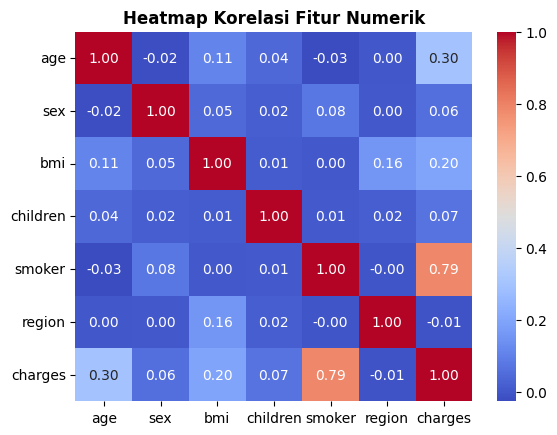

In [12]:
# Heatmap Korelasi
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,      #menampilkan angka
    fmt='.2f',       #format desimal
    cmap='coolwarm', #warna
)

plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.show()

**Justifikasi Pemilihan Fitur**

Pemilihan fitur input didasarkan pada kombinasi analisis korelasi menggunakan framework Cohen (1988) dan pertimbangan domain knowledge asuransi kesehatan.

| Fitur | Korelasi (r) | Kategori | Justifikasi |
|---|---|---|---|
| age | 0.30 | Medium effect | Lolos threshold medium (r ≥ 0.30). Usia berpengaruh langsung terhadap risiko kesehatan |
| smoker | 0.79 | Large effect | Korelasi tertinggi. Status perokok merupakan faktor risiko utama dalam penetapan premi |
| bmi | 0.20 | Small effect | Tidak lolos threshold medium, namun ditambahkan karena BMI merupakan indikator kesehatan yang secara domain knowledge berpengaruh terhadap biaya kesehatan |
| bmi_smoker | — | Feature engineering | Fitur interaksi bmi × smoker untuk menangkap efek gabungan antara obesitas dan kebiasaan merokok yang tidak dapat ditangkap secara linear |
| children | 0.07 | Very small effect | Di bawah threshold, namun ditambahkan berdasarkan domain knowledge bahwa jumlah tanggungan merupakan faktor umum dalam penetapan premi asuransi |

**Referensi threshold:** Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

### **3.5 Penanganan Missing Values**
Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing values sehingga tidak diperlukan proses penanganan data hilang.



### **3.6 Feature Engineering: Fitur Interaksi BMI × Smoker**

Berdasarkan hasil diagnostik data, teridentifikasi adanya pola non-linear pada hubungan antara BMI dan charges yang dipengaruhi oleh status perokok. Perokok dengan BMI tinggi cenderung memiliki charges yang jauh lebih tinggi dibandingkan non-perokok dengan BMI serupa.

Untuk menangkap pola interaksi ini, dibuat fitur baru berupa hasil perkalian antara BMI dan status perokok:

$$\text{bmi_smoker} = \text{bmi} \times \text{smoker}$$

Fitur interaksi ini memungkinkan model menangkap efek gabungan antara obesitas dan kebiasaan merokok terhadap biaya asuransi kesehatan.

In [13]:
# Tambah fitur interaksi bmi x smoker
df['bmi_smoker'] = df['bmi'] * df['smoker']

X     = df[['age', 'smoker', 'bmi', 'bmi_smoker', 'children']]
y_log = np.log(df['charges'])

print("Fitur:", X.columns.tolist())
print("Shape X    :", X.shape)
print("Shape y_log:", y_log.shape)

Fitur: ['age', 'smoker', 'bmi', 'bmi_smoker', 'children']
Shape X    : (1337, 5)
Shape y_log: (1337,)


### **3.7 Log Transformasi Target (Charges)**

Berdasarkan hasil diagnostik, variabel target charges memiliki skewness sebesar 1.51 yang tergolong right-skewed. Kondisi ini menyebabkan model kesulitan mempelajari pola pada rentang charges tinggi karena distribusi data tidak simetris.

Untuk mengatasi hal ini, diterapkan transformasi logaritma natural pada variabel target:

$$y' = \ln(\text{charges})$$

Transformasi ini bertujuan untuk:
1. Mengurangi skewness sehingga distribusi mendekati normal
2. Memperkecil pengaruh nilai ekstrem (charges sangat tinggi)
3. Membantu model belajar pola secara lebih merata di seluruh rentang nilai

Setelah prediksi dilakukan, nilai hasil prediksi dikembalikan ke skala asli menggunakan fungsi eksponensial:

$$\text{charges} = e^{y'}$$

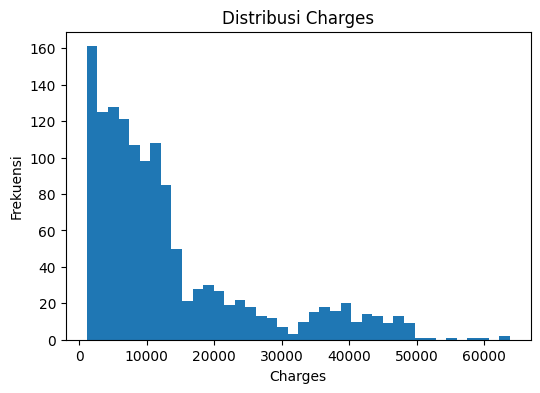

In [14]:
plt.figure(figsize=(6,4))          # ukuran grafik (lebar = 6 inci, tinggi = 4 inci)
plt.hist(df['charges'], bins=40)   # membuat histogram
plt.title('Distribusi Charges')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.show()

Skewness sebelum log transform : 1.5137
Skewness sesudah log transform  : -0.0897


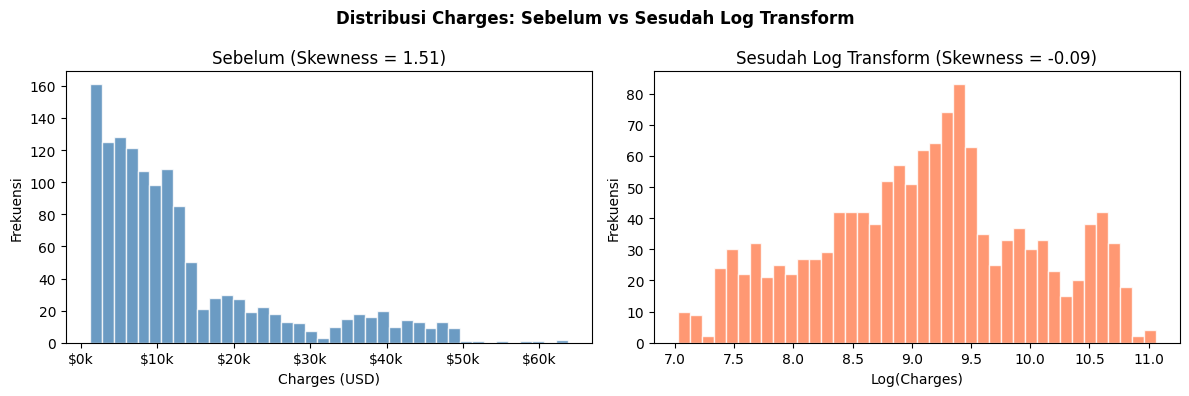

In [15]:
y_log = np.log(df['charges'])

# Cek skewness sebelum dan sesudah
from scipy.stats import skew
print(f"Skewness sebelum log transform : {skew(df['charges']):.4f}")
print(f"Skewness sesudah log transform  : {skew(y_log):.4f}")

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Charges: Sebelum vs Sesudah Log Transform', fontweight='bold')

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Sebelum (Skewness = {skew(df["charges"]):.2f})')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[1].hist(y_log, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Sesudah Log Transform (Skewness = {skew(y_log):.2f})')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### **3.8 Standarisasi Fitur (Scaling)**

Standarisasi dilakukan menggunakan `StandardScaler` untuk menyamakan skala antar fitur. Hal ini krusial bagi model berbasis jarak seperti **KNN**, agar fitur dengan rentang nilai besar tidak mendominasi perhitungan jarak.

Rumus Z-Score Standardization:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:
* $x$ = nilai asli
* $\mu$ = rata-rata fitur
* $\sigma$ = standar deviasi fitur

In [16]:
# Inisialisasi Scaler
scaler = StandardScaler()

# Fitur yang akan di-scale (semua fitur input)
X_scaled = scaler.fit_transform(X)

print("Scaling berhasil dilakukan pada fitur:", X.columns.tolist())
print("Contoh data setelah scaling (5 baris pertama):")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Scaling berhasil dilakukan pada fitur: ['age', 'smoker', 'bmi', 'bmi_smoker', 'children']
Contoh data setelah scaling (5 baris pertama):


,age,smoker,bmi,bmi_smoker,children
0,-1.440418,1.969660,-0.453160,1.698613,-0.909234
1,-1.511647,-0.507702,0.509422,-0.494746,-0.079442
2,-0.799350,-0.507702,0.383155,-0.494746,1.580143
3,-0.443201,-0.507702,-1.305052,-0.494746,-0.909234
4,-0.514431,-0.507702,-0.292456,-0.494746,-0.909234


---
## **4. Penanganan Imbalanced Data**

Penelitian ini menggunakan pendekatan regresi untuk mengestimasi biaya asuransi kesehatan (charges) yang berupa data numerik kontinu. Oleh karena itu, permasalahan ketidakseimbangan kelas (imbalanced data) yang umumnya ditemukan pada tugas klasifikasi tidak menjadi fokus pada penelitian ini. Dengan demikian, teknik penanganan data tidak seimbang seperti SMOTE, undersampling, oversampling, maupun class weighting tidak diterapkan.

Meskipun distribusi target charges cenderung tidak simetris (right-skewed), penelitian ini tetap menggunakan data asli tanpa teknik penyeimbangan data karena target yang diprediksi merupakan variabel kontinu.

---
## **5. Metode dan Eksperimen**

### **5.1. Konsep Algoritma**

**1. K-Nearest Neighbors Regressor**  
K-Nearest Neighbor (KNN) merupakan algoritma machine learning yang melakukan prediksi berdasarkan sejumlah tetangga terdekat dari suatu data. Pada penelitian ini, KNN digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Jarak antar data biasanya dihitung menggunakan Euclidean Distance:

**Rumus Euclidean Distance:**

$$d(x, x_i) = \sqrt{\sum_{j=1}^{n}(x_j - x_{ij})^2}$$

**Keterangan:**
- $d(x, x_i)$ = jarak antara data baru $x$ dengan data latih $x_i$
- $x_j$ = nilai fitur ke-$j$ pada data baru
- $x_{ij}$ = nilai fitur ke-$j$ pada data latih ke-$i$
- $n$ = jumlah fitur
Semakin dekat jarak antar data, semakin besar pengaruh data tersebut terhadap hasil prediksi.

setelah jarak sudah memilih data yang ingin diprediksi,selanjutnya nilai prediksi diperoleh melalui rumus :

$$\hat{y} = \frac{1}{K} \sum_{i=1}^{K} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $K$ = jumlah tetangga terdekat yang dipilih
- $y_i$ = nilai target dari tetangga ke-$i$

**2. Decision Tree**

Decision Tree Regressor membangun struktur pohon keputusan dengan memilih pemisahan data yang menghasilkan nilai Mean Squared Error (MSE) terkecil pada setiap node. Proses ini dilakukan secara berulang hingga diperoleh struktur pohon yang mampu memprediksi nilai target dengan tingkat kesalahan yang minimum.

Rumus MSE:
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y})^2$$

**Keterangan:**
- $y_i$ = nilai target aktual
- $\hat{y}$ = rata-rata nilai target pada node tersebut
- $n$ = jumlah data pada node


Nilai prediksi akhir diperoleh dari rata-rata nilai target pada *leaf node*:

$$\hat{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $y_i$ = nilai target aktual pada node
- $n$ = jumlah data pada leaf node

Pada penelitian ini, Decision Tree digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Keunggulan Decision Tree:


* Mudah dipahami
* Tidak memerlukan asumsi distribusi data
* Mampu menangani hubungan non-linear



### **5.2 Cross Validation**
Penelitian ini menggunakan metode K-Fold Cross Validation untuk mengevaluasi performa model. Pada metode ini, dataset dibagi menjadi beberapa bagian. Secara bergantian satu bagian digunakan sebagai data pengujian dan bagian lainnya digunakan sebagai data pelatihan. Metode ini dipilih karena mampu menghasilkan evaluasi yang lebih stabil dibandingkan pembagian data sederhana menggunakan train-test split.

#### **5.2.1 Analisis Stabilitas N-Splits**

Untuk memvalidasi pemilihan nilai n_splits = 5, dilakukan eksperimen perbandingan stabilitas model pada berbagai nilai n_splits (3, 5, 7, 10). Stabilitas diukur menggunakan standar deviasi R² antar fold. Jika semakin kecil nilai standar deviasi, maka semakin stabil hasil evaluasi model.

Nilai n_splits terbaik dipilih berdasarkan kombinasi:
- R² rata-rata tertinggi = model lebih akurat
- Std R² terendah = model lebih stabil dan konsisten antar fold

In [17]:
# Analisis stabilitas n_splits
splits_to_test = [3, 5, 7, 10]
models_to_test = {
    'KNN'          : (KNeighborsRegressor(n_neighbors=32), X_scaled),
    'Decision Tree': (DecisionTreeRegressor(random_state=42, max_depth=5), X),
}

stability_results = []

for n in splits_to_test:
    kf_temp = KFold(n_splits=n, shuffle=True, random_state=42)
    for model_name, (model, X_input) in models_to_test.items():
        scores = cross_val_score(model, X_input, y_log, cv=kf_temp, scoring='r2')
        stability_results.append({
            'n_splits' : n,
            'Model'    : model_name,
            'R² Mean'  : round(scores.mean(), 4),
            'R² Std'   : round(scores.std(), 4),
        })

stability_df = pd.DataFrame(stability_results)
print(stability_df.to_string(index=False))

 n_splits         Model  R² Mean  R² Std
        3           KNN   0.8221  0.0147
        3 Decision Tree   0.8231  0.0132
        5           KNN   0.8206  0.0285
        5 Decision Tree   0.8184  0.0328
        7           KNN   0.8183  0.0322
        7 Decision Tree   0.8194  0.0340
       10           KNN   0.8181  0.0442
       10 Decision Tree   0.8203  0.0472


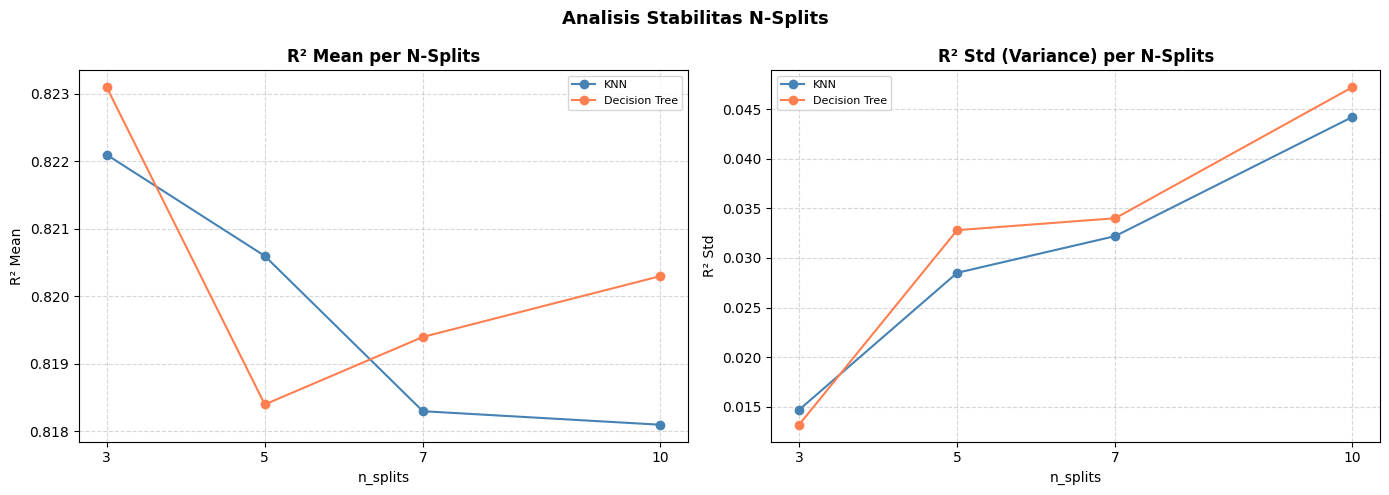

In [18]:
# Visualisasi stabilitas n_splits per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Stabilitas N-Splits', fontsize=13, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
model_list = list(models_to_test.keys())

# Plot R² Mean
for i, model_name in enumerate(model_list):
    subset = stability_df[stability_df['Model'] == model_name]
    axes[0].plot(
        subset['n_splits'], subset['R² Mean'],
        marker='o', label=model_name, color=colors[i]
    )
axes[0].set_title('R² Mean per N-Splits', fontweight='bold')
axes[0].set_xlabel('n_splits')
axes[0].set_ylabel('R² Mean')
axes[0].set_xticks(splits_to_test)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot R² Std
for i, model_name in enumerate(model_list):
    subset = stability_df[stability_df['Model'] == model_name]
    axes[1].plot(
        subset['n_splits'], subset['R² Std'],
        marker='o', label=model_name, color=colors[i]
    )
axes[1].set_title('R² Std (Variance) per N-Splits', fontweight='bold')
axes[1].set_xlabel('n_splits')
axes[1].set_ylabel('R² Std')
axes[1].set_xticks(splits_to_test)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
print(kf)

KFold(n_splits=3, random_state=42, shuffle=True)


### **5.3 Hyperparameter Tuning dengan GridSearchCV**
GridSearchCV digunakan untuk mencari kombinasi parameter terbaik secara otomatis dengan mencoba seluruh kombinasi parameter yang telah ditentukan dan mengevaluasinya menggunakan Cross Validation.

In [20]:
# KNN
param_knn = {
    'n_neighbors': range(1, 51),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_knn,
    cv=kf,
    scoring='r2'
)

grid_knn.fit(X_scaled, y_log)
print("Best params KNN:", grid_knn.best_params_)

Best params KNN: {'metric': 'manhattan', 'n_neighbors': 32, 'weights': 'uniform'}


Hasil tersebut menunjukkan bahwa model KNN dengan 32 tetangga terdekat menghasilkan nilai R² tertinggi dibandingkan nilai n_neighbors lainnya yang diuji. Oleh karena itu, nilai n_neighbors = 32 digunakan pada model KNN akhir untuk proses evaluasi dan perbandingan dengan algoritma Decision Tree.

In [21]:
# Decision Tree
param_dt = {
    'max_depth'        : [3, 5, 7, 9, 11, 13, None],
    'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'min_samples_leaf' : [1, 2, 4, 6, 8, 10],
    'criterion'        : ['squared_error', 'friedman_mse']
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_dt,
    cv=kf,
    scoring='r2'
)

grid_dt.fit(X, y_log)
print("Best params DT:", grid_dt.best_params_)

Best params DT: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


Berdasarkan hasil pencarian, kombinasi parameter terbaik yang diperoleh adalah max_depth = 5 dan min_samples_split = 2. Kombinasi tersebut menghasilkan nilai R² tertinggi pada proses 3-Fold Cross Validation sehingga digunakan pada model Decision Tree akhir.

---
## **6. Hasil & Analisis**

## **6.1. Tabel Perbandingan Metrik**
Evaluasi kinerja model dilakukan menggunakan lima metrik regresi, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE) dan Coefficient of Determination (R² Score). Kelima metrik tersebut digunakan untuk mengukur tingkat kesalahan prediksi serta kemampuan model dalam menjelaskan variasi data target.

**Mean Absolute Error (MAE)**

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

Rumus:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MAE, semakin baik performa model.

**Mean Squared Error (MSE)**

MSE mengukur rata-rata kuadrat kesalahan antara nilai aktual dan nilai prediksi.

Rumus:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MSE, semakin baik performa model. Metrik ini memberikan penalti yang lebih besar terhadap kesalahan prediksi yang besar.

**R² Score**

R² Score mengukur kemampuan model dalam menjelaskan variasi data target.

Rumus:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Keterangan:

* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi
* $\bar{y}$ = rata-rata nilai aktual

Nilai R² berada pada rentang (−∞,1]. Semakin mendekati 1, semakin baik kemampuan model dalam menjelaskan variasi data.

**Mean Absolute Percentage Error (MAPE)**

MAPE mengukur rata-rata persentase kesalahan prediksi terhadap nilai aktual.

Rumus:
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Keterangan:

* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

In [22]:
knn_best = grid_knn.best_estimator_
dt_best  = grid_dt.best_estimator_

knn_pred_log = cross_val_predict(knn_best, X_scaled, y_log, cv=kf)
dt_pred_log  = cross_val_predict(dt_best,  X,        y_log, cv=kf)

y_actual = np.exp(y_log)
knn_pred = np.exp(knn_pred_log)
dt_pred  = np.exp(dt_pred_log)

preds_all   = [knn_pred, dt_pred]
model_names = ['KNN', 'Decision Tree']

In [23]:
print("knn_pred_log — min:", knn_pred_log.min(), "| max:", knn_pred_log.max())
print("dt_pred_log  — min:", dt_pred_log.min(),  "| max:", dt_pred_log.max())
print("y_log        — min:", y_log.min(),             "| max:", y_log.max())

print("\nAda inf di knn_pred:", np.any(np.isinf(knn_pred)))
print("Ada inf di dt_pred :", np.any(np.isinf(dt_pred)))
print("Ada nan di knn_pred:", np.any(np.isnan(knn_pred)))
print("Ada nan di dt_pred :", np.any(np.isnan(dt_pred)))

print("\ny_actual min:", y_actual.min(), "| max:", y_actual.max())

knn_pred_log — min: 7.543319594334534 | max: 10.736276026702708
dt_pred_log  — min: 7.417311531527772 | max: 10.8141320220299
y_log        — min: 7.02275569117477 | max: 11.063044851063491

Ada inf di knn_pred: False
Ada inf di dt_pred : False
Ada nan di knn_pred: False
Ada nan di dt_pred : False

y_actual min: 1121.8738999999996 | max: 63770.428010000025


In [24]:
# Implementasi Evaluasi (skala asli)
mae_knn  = mean_absolute_error(y_actual, knn_pred)
mse_knn  = mean_squared_error(y_actual, knn_pred)
rmse_knn = sqrt(mse_knn)
r2_knn   = r2_score(y_actual, knn_pred)
mape_knn = mean_absolute_percentage_error(y_actual, knn_pred) * 100

mae_dt   = mean_absolute_error(y_actual, dt_pred)
mse_dt   = mean_squared_error(y_actual, dt_pred)
rmse_dt  = sqrt(mse_dt)
r2_dt    = r2_score(y_actual, dt_pred)
mape_dt  = mean_absolute_percentage_error(y_actual, dt_pred) * 100

In [25]:
# Tabel Perbandingan Metrik
results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'MAE'  : [mae_knn, mae_dt],
    'MSE'  : [mse_knn, mse_dt],
    'RMSE' : [rmse_knn, rmse_dt],
    'MAPE' : [mape_knn, mape_dt],
    'R²'   : [r2_knn, r2_dt]
})

results.style.format({
    'MAE' : '{:,.4f}',
    'MSE' : '{:,.4f}',
    'RMSE': '{:,.4f}',
    'MAPE': '{:.2f}%',
    'R²'  : '{:.4f}'
})

,Model,MAE,MSE,RMSE,MAPE,R²
0,KNN,"2,442.5716","23,941,408.6794","4,892.9959",19.41%,0.8366
1,Decision Tree,"2,205.7376","21,645,681.7663","4,652.4920",18.77%,0.8523


In [26]:
# Komparasi dengan vs tanpa bmi_smoker
def evaluate_features(X_raw, label):
    kf_s = KFold(n_splits=3, shuffle=True, random_state=42)
    y_lg = np.log(df['charges'])

    scaler_s = StandardScaler()
    X_sc     = scaler_s.fit_transform(X_raw)

    # KNN
    g_knn = GridSearchCV(
        KNeighborsRegressor(),
        {'n_neighbors': range(1, 51),
         'weights'    : ['uniform', 'distance'],
         'metric'     : ['euclidean', 'manhattan']},
        cv=kf_s, scoring='r2'
    )
    g_knn.fit(X_sc, y_lg)

    # DT
    g_dt = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        {'max_depth'        : [3, 5, 7, 9, 11, 13, None],
         'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
         'min_samples_leaf' : [1, 2, 4, 6, 8, 10],
         'criterion'        : ['squared_error', 'friedman_mse']},
        cv=kf_s, scoring='r2'
    )
    g_dt.fit(X_raw, y_lg)

    knn_log = cross_val_predict(g_knn.best_estimator_, X_sc,  y_lg, cv=kf_s)
    dt_log  = cross_val_predict(g_dt.best_estimator_,  X_raw, y_lg, cv=kf_s)

    y_act = np.exp(y_lg)
    rows  = []
    for name, pred in [('KNN', np.exp(knn_log)), ('Decision Tree', np.exp(dt_log))]:
        rows.append({
            'Fitur'   : label,
            'Model'   : name,
            'MAE'     : f"${mean_absolute_error(y_act, pred):,.2f}",
            'RMSE'    : f"${sqrt(mean_squared_error(y_act, pred)):,.2f}",
            'MAPE'    : f"{mean_absolute_percentage_error(y_act, pred)*100:.2f}%",
            'R²'      : f"{r2_score(y_act, pred):.4f}",
        })
    return rows

print("Menjalankan tanpa bmi_smoker...")
df['bmi_smoker'] = df['bmi'] * df['smoker']
X_tanpa = df[['age', 'smoker', 'bmi', 'children']]
rows_tanpa = evaluate_features(X_tanpa, 'Tanpa bmi_smoker')

print("Menjalankan dengan bmi_smoker...")
X_dengan = df[['age', 'smoker', 'bmi', 'bmi_smoker', 'children']]
rows_dengan = evaluate_features(X_dengan, 'Dengan bmi_smoker')

# Tabel perbandingan
comp_bmi = pd.DataFrame(rows_tanpa + rows_dengan)
print("\n")
print(comp_bmi.to_string(index=False))

Menjalankan tanpa bmi_smoker...
Menjalankan dengan bmi_smoker...


            Fitur         Model       MAE      RMSE   MAPE     R²
 Tanpa bmi_smoker           KNN $2,535.42 $4,981.67 19.59% 0.8307
 Tanpa bmi_smoker Decision Tree $2,243.29 $4,651.03 19.03% 0.8524
Dengan bmi_smoker           KNN $2,442.57 $4,893.00 19.41% 0.8366
Dengan bmi_smoker Decision Tree $2,205.74 $4,652.49 18.77% 0.8523


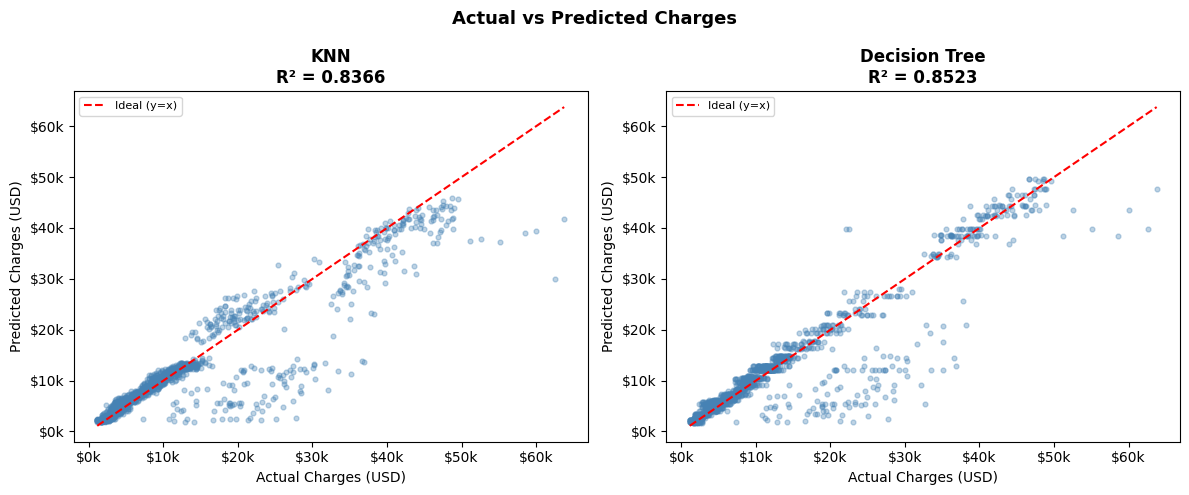

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Actual vs Predicted Charges', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    r2 = r2_score(y_actual, pred)
    ax.scatter(y_actual, pred, alpha=0.35, s=12, color='steelblue')
    lims = [min(y_actual.min(), pred.min()), max(y_actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
    ax.set_xlabel('Actual Charges (USD)')
    ax.set_ylabel('Predicted Charges (USD)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

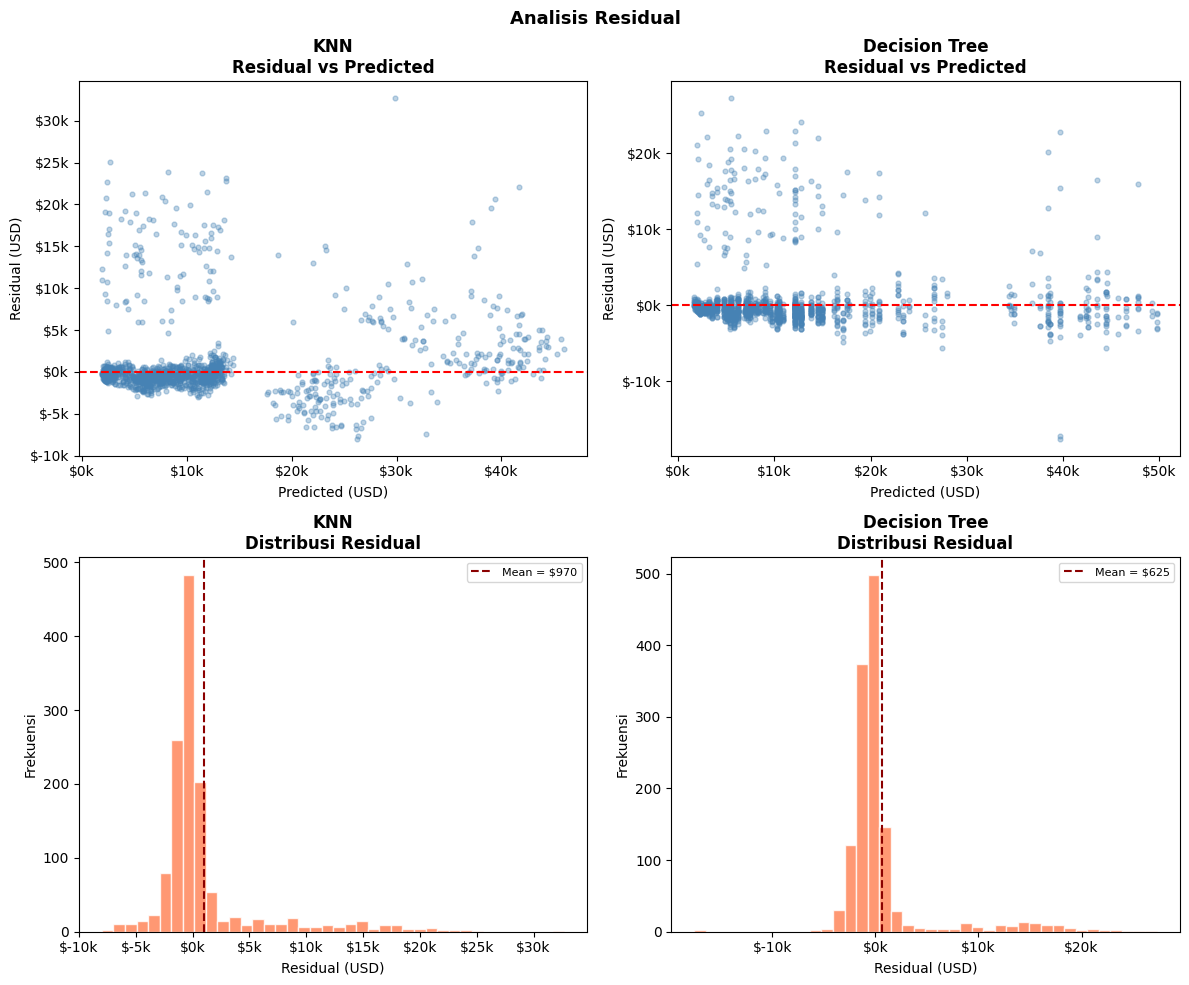

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analisis Residual', fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds_all)):
    residuals = np.array(y_actual) - np.array(pred)

    axes[0, i].scatter(pred, residuals, alpha=0.35, s=12, color='steelblue')
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nResidual vs Predicted', fontweight='bold')
    axes[0, i].set_xlabel('Predicted (USD)')
    axes[0, i].set_ylabel('Residual (USD)')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    axes[1, i].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[1, i].axvline(residuals.mean(), color='darkred', linestyle='--',
                       linewidth=1.5, label=f'Mean = ${residuals.mean():,.0f}')
    axes[1, i].set_title(f'{name}\nDistribusi Residual', fontweight='bold')
    axes[1, i].set_xlabel('Residual (USD)')
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=8)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

## **7. Kesimpulan**

Penelitian ini membandingkan kinerja dua algoritma regresi, yaitu **K-Nearest Neighbor (KNN)** dan **Decision Tree**, dalam mengestimasi biaya asuransi kesehatan menggunakan fitur *age, smoker, bmi, bmi_smoker,* dan *children*.

**Temuan Utama:**
Berdasarkan hasil evaluasi menggunakan 3-Fold Cross Validation, **Decision Tree** menunjukkan performa terbaik secara keseluruhan dengan nilai R% tertinggi (~0.8523) dan tingkat kesalahan (MAE, MSE, RMSE, MAPE) terendah dibandingkan KNN.

*   **KNN (K-Nearest Neighbors)**: Menghasilkan performa yang solid (R% ~0.8366), namun sangat bergantung pada proses *scaling* fitur karena berbasis jarak Euclidean. Model ini cenderung lebih sensitif terhadap nilai ekstrem pada segmen biaya tinggi.
*   **Decision Tree**: Mampu menangkap hubungan non-linear dan interaksi fitur secara lebih efektif tanpa memerlukan asumsi distribusi data atau *scaling*. Pengaturan *hyperparameter* (seperti `max_depth`) terbukti krusial untuk mencegah *overfitting*.

**Rekomendasi:**
1.  **Log Transformasi**: Penggunaan transformasi logaritma pada variabel target sangat disarankan untuk data biaya asuransi yang memiliki *skewness* tinggi agar model lebih stabil.
2.  **Feature Engineering**: Penambahan fitur interaksi seperti `bmi_smoker` terbukti membantu model dalam memisahkan kelompok data dengan profil risiko tinggi.
3.  **Analisis Lanjutan**: Meskipun Decision Tree unggul, pemantauan terhadap *residual* tetap diperlukan untuk memastikan model tidak memberikan estimasi yang terlalu jauh (bias) pada kelompok usia tertentu.

In [29]:
# Tabel Ringkasan Metrik — Perbandingan KNN dan Decision Tree
results_summary = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'MAE'  : [mae_knn, mae_dt],
    'MSE'  : [mse_knn, mse_dt],
    'RMSE' : [rmse_knn, rmse_dt],
    'MAPE' : [mape_knn, mape_dt],
    'R²'   : [r2_knn, r2_dt]
})

results_display = results_summary.copy()
results_display['MAE']  = results_summary['MAE'].apply(lambda x: f'${x:,.2f}')
results_display['MSE']  = results_summary['MSE'].apply(lambda x: f'${x:,.2f}')
results_display['RMSE'] = results_summary['RMSE'].apply(lambda x: f'${x:,.2f}')
results_display['MAPE'] = results_summary['MAPE'].apply(lambda x: f'{x:.2f}%')
results_display['R²']   = results_summary['R²'].apply(lambda x: f'{x:.4f}')

display(results_display)

# Kamus untuk memudahkan pencarian model terbaik
metrics = {
    'R²'  : {'vals': {'KNN': r2_knn, 'Decision Tree': r2_dt}, 'best': 'max'},
    'MAE' : {'vals': {'KNN': mae_knn, 'Decision Tree': mae_dt}, 'best': 'min'},
    'MSE' : {'vals': {'KNN': mse_knn, 'Decision Tree': mse_dt}, 'best': 'min'},
    'RMSE': {'vals': {'KNN': rmse_knn, 'Decision Tree': rmse_dt}, 'best': 'min'},
    'MAPE': {'vals': {'KNN': mape_knn, 'Decision Tree': mape_dt}, 'best': 'min'}
}

print("\n--- Ringkasan Model Terbaik ---")
for m_name, m_info in metrics.items():
    if m_info['best'] == 'max':
        best_model = max(m_info['vals'], key=m_info['vals'].get)
    else:
        best_model = min(m_info['vals'], key=m_info['vals'].get)

    val = m_info['vals'][best_model]
    formatted_val = f"${val:,.2f}" if m_name in ['MAE', 'MSE', 'RMSE'] else (f"{val:.2f}%" if m_name == 'MAPE' else f"{val:.4f}")
    print(f"Model dengan {m_name} terbaik : {best_model} ({formatted_val})")

,Model,MAE,MSE,RMSE,MAPE,R²
0,KNN,"$2,442.57","$23,941,408.68","$4,893.00",19.41%,0.8366
1,Decision Tree,"$2,205.74","$21,645,681.77","$4,652.49",18.77%,0.8523



--- Ringkasan Model Terbaik ---
Model dengan R² terbaik : Decision Tree (0.8523)
Model dengan MAE terbaik : Decision Tree ($2,205.74)
Model dengan MSE terbaik : Decision Tree ($21,645,681.77)
Model dengan RMSE terbaik : Decision Tree ($4,652.49)
Model dengan MAPE terbaik : Decision Tree (18.77%)


In [30]:
!pip freeze > requirements.txt

In [32]:
!echo "name: colab_env" > environment.yml
!echo "dependencies:" >> environment.yml
!echo "  - python=3.10" >> environment.yml
!echo "  - pip" >> environment.yml
!echo "  - pip:" >> environment.yml
!sed 's/^/    - /' requirements.txt >> environment.yml